# Logistic regression 

## Initialize

In [1]:
# import required libraries
import numpy as np
from numpy.polynomial.polynomial import Polynomial
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import tensorflow as tf #type: ignore
import torch #type: ignore
import torch.nn.functional as F #type: ignore
#
from IPython.display import display, Math
# Import typyng library for type hinting
from typing import Callable, Union, List, Any, Tuple
#
# Initialize pretty printing
sp.init_printing()

## Logistic function (sigmoid)

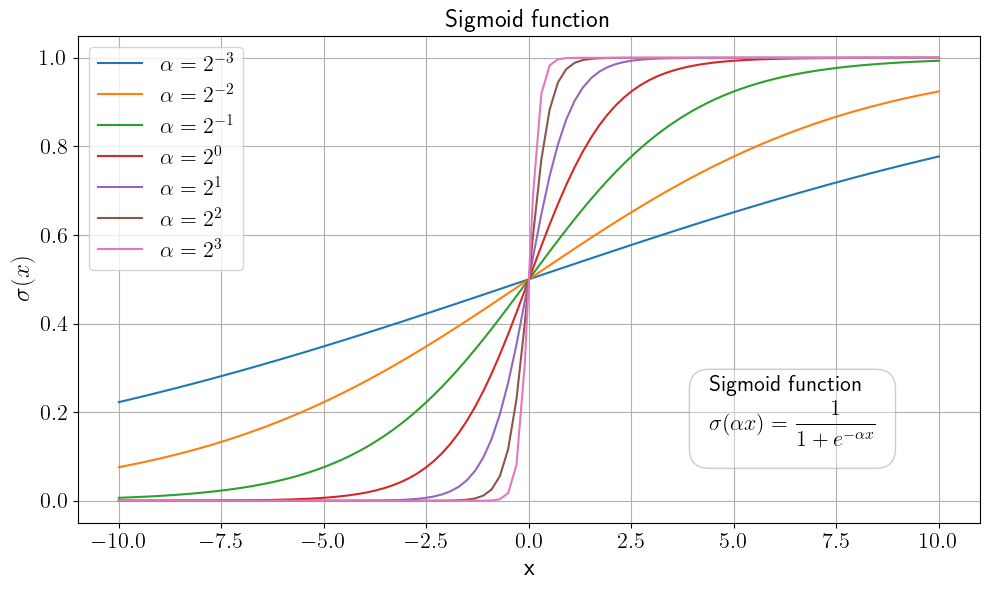

In [2]:
# Show plot of the sigmoit function for different values of alpha
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

x = np.linspace(-10, 10, 100)
plt.figure(figsize=(10, 6))
for i in range(-3, 4):
    alpha = 2**i
    y = 1 / (1 + np.exp(-alpha * x))
    plt.plot(x, y, label=r"$\alpha=2^{%d}$" % i)
    
plt.text(
            0.7, 0.3,
            'Sigmoid function\n' + r'$\displaystyle\sigma(\alpha x) = \frac{1}{1 + e^{-\alpha x}}$',
            transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
            horizontalalignment='left',     # Align text to the right edge of the box
            verticalalignment='top',         # Align text to the top edge of the box
            fontsize=16,
            color='black',
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.4, boxstyle='round,pad=0.9')
)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel("x", fontsize = 18)
plt.ylabel(r"$\sigma(x)$", fontsize = 18)
plt.legend(loc='upper left', fontsize = 16)
plt.grid(True)
plt.title("Sigmoid function", fontsize = 18)
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_linear.pdf')
plt.show()

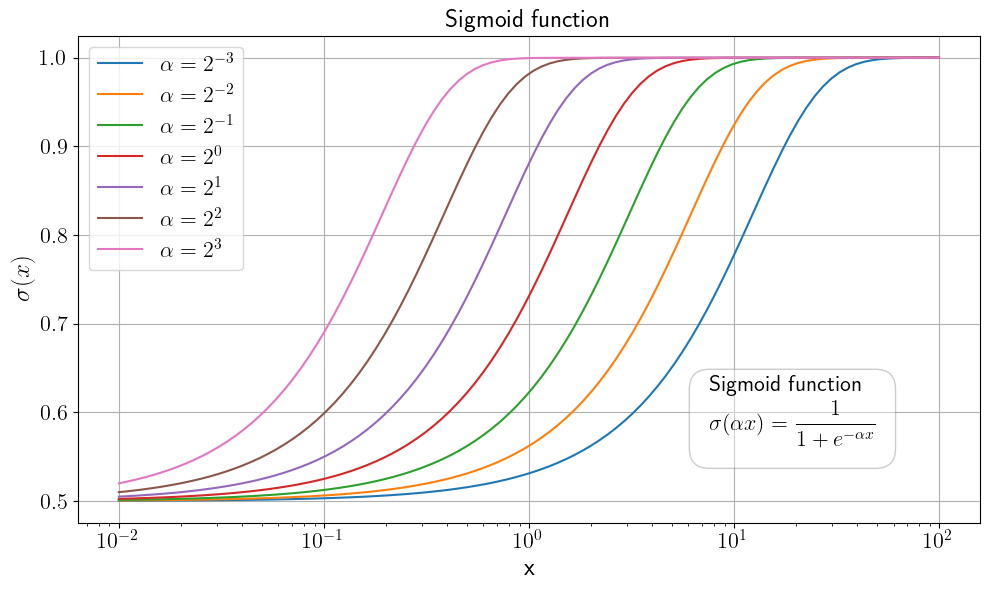

In [3]:
# Show plot of the sigmoit function for different values of alpha in log scale
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

x = np.logspace(-2, 2, 100)
plt.figure(figsize=(10, 6))
for i in range(-3, 4):
    alpha = 2**i
    y = 1 / (1 + np.exp(-alpha * x))
    plt.plot(x, y, label=r"$\alpha=2^{%d}$" % i)
    
plt.text(
            0.7, 0.3,
            'Sigmoid function\n' + r'$\displaystyle\sigma(\alpha x) = \frac{1}{1 + e^{-\alpha x}}$',
            transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
            horizontalalignment='left',     # Align text to the right edge of the box
            verticalalignment='top',         # Align text to the top edge of the box
            fontsize=16,
            color='black',
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.4, boxstyle='round,pad=0.9')
)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel("x", fontsize = 18)
plt.ylabel(r"$\sigma(x)$", fontsize = 18)
plt.legend(loc='upper left', fontsize = 16)
plt.grid(True)
plt.title("Sigmoid function", fontsize = 18)
plt.xscale('log')
plt.tight_layout()
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_log.pdf')
plt.show()

## Numpy

### Deterministic model (linear data - linear model)

In [2]:
# Define symbols
x = sp.symbols('x', real=True)
omega0, omega1 = sp.symbols('omega0 omega1', real=True)

# Define the polynomial: poly(omega0, omega1, 0, 0, x) = omega0 + omega1*x
poly = omega0 + omega1 * x

# Define the logistic function: y(omega, x) = 1/(1 + exp(-poly))
y = 1/(1 + sp.exp(-poly))

# Set the true parameters (omega_true = {2, -3})
omega_true = {omega0: 2, omega1: -3}

# Solve for x such that y(omega_true, x) == 0.5
solution = sp.solve(sp.Eq(y.subs(omega_true), 0.5), x)
db = solution[0]

print("Decision boundary x =", db)

Decision boundary x = 0.666666666666667


In [3]:
def poly(x: float, omega: np.ndarray) -> float:
    """Evaluates a polynomial with coefficients omega at x.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients of the polynomial.
        
    Returns
    -------
    float
        Polynomial value.
    """
    output: float = 0.0
    for i, omega_i in enumerate(omega):
        output += omega_i * x**i
    return output

def p(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [4]:
# Define the true parameters
omega_true = np.array([2, -3])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result = minimize(objective, initial_x, args=(omega_true,))

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_approx, initial_x, args=(omega_true,))

print("Decision boundary x =", result.x[0])
print("Objective value =", result.fun)
decision_boundary = result.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.6666669622623926
Objective value = 4.914946870639898e-14
Decision boundary (from approx solution) x = 0.6666666593080686
Objective value (from approx solution) = 3.0458793996399694e-17


In [5]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true)
p_val = p(x_val, omega_true)
p_test = p(x_test, omega_true)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

In [9]:
Y_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [10]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 0.99502488 -1.49253731]
Decision boundary (from approx solution) x = 0.6666666593080686


In [15]:
def Y_pred(p: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1/len(Y) * res

In [16]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, [0,0])
omega_exact = result.x
omega_exact

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeW

array([ 238.78179384, -353.24930683])

In [18]:
loss_fn(X_train, p_train, omega_true)

In [17]:
loss_fn(X_train, p_train, omega_exact)

In [18]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 0.2555982066525436
Validation loss: 0.2525623983758045
Test loss: 0.2525623983758045


In [20]:
train_loss = loss_fn(X_train, Y_train, omega_exact)
val_loss = loss_fn(X_val, Y_val, omega_exact)
test_loss = loss_fn(X_test, Y_test, omega_exact)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 0.00011278442394541344
Validation loss: 1.0968681053782347e-05
Test loss: inf


/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))


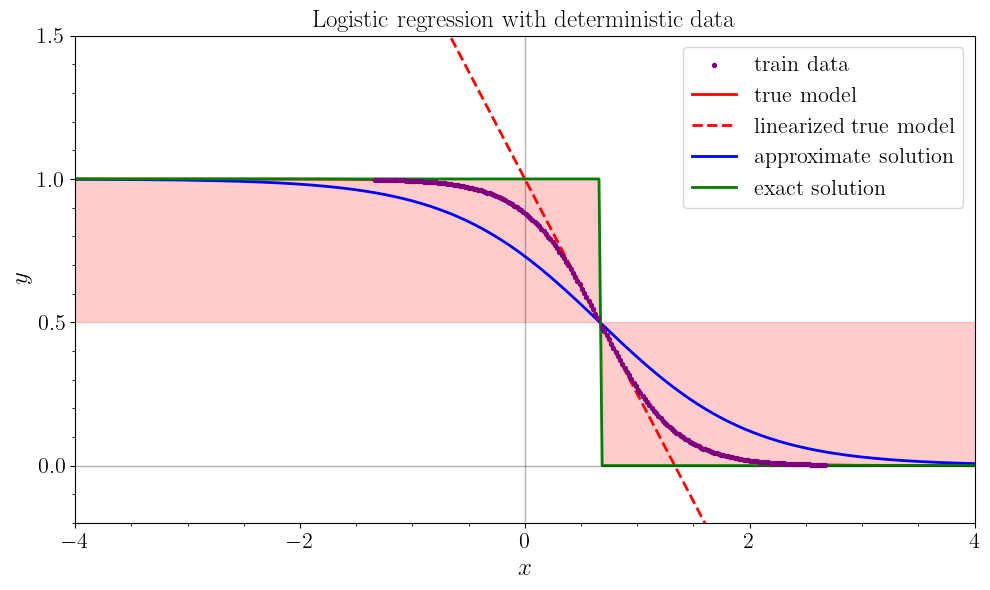

In [21]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, H(decision_boundary - x_plot), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, H(decision_boundary - x_plot), 0.5, where=(H(decision_boundary - x_plot) < 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(decision_boundary - x_plot), where=(H(decision_boundary - x_plot) > 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution.pdf')
plt.show()

In [22]:
ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
ypred = Y_pred(p(x_train, omega_approx), threshold=0.5)

TP = np.sum((ypred == 1) & (ytrue == 1))
FP = np.sum((ypred == 1) & (ytrue == 0))
FN = np.sum((ypred == 0) & (ytrue == 1))
TN = np.sum((ypred == 0) & (ytrue == 0))

confusion_matrix = np.array([[TP, FP],
                             [FN, TN]])

print(confusion_matrix)

[[100   0]
 [  0 100]]


In [23]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

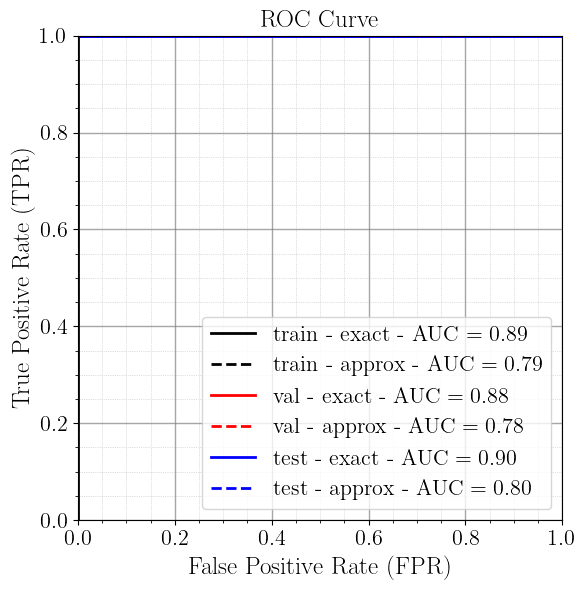

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_true, p_train)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_true, p_val)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_true, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the plot range.
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set the aspect ratio to 1.
ax.set_aspect('equal')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_roc.pdf')

plt.show()

### Probabilistic model (linear data - linear model)

In [25]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [26]:
# Define the true parameters
omega_true = np.array([2, -3])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary x =", result.x[0])
print("Objective value =", result.fun)
decision_boundary = result.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.6666669622623926
Objective value = 4.914946870639898e-14
Decision boundary (from approx solution) x = 0.6666666593080686
Objective value (from approx solution) = 3.0458793996399694e-17


In [27]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true, noise_std=1)
p_val = p(x_val, omega_true, noise_std=1)
p_test = p(x_test, omega_true, noise_std=1)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
print("Validation data for class 1:", np.count_nonzero(Y_val), "out of", len(Y_val))
print("Test data for class 1:", np.count_nonzero(Y_test), "out of", len(Y_test))

Train data for class 1: 106 out of 200
Validation data for class 1: 46 out of 100
Test data for class 1: 47 out of 100


In [28]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 1.06872174 -1.42308261]
Decision boundary (from approx solution) x = 0.6666666593080686


In [29]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1/len(Y) * res

In [30]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x
print("Exact omega:", omega_exact)

Exact omega: [ 3.43811437 -4.35590151]


In [31]:
# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective_exact(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')

# Optimize using minimize; here we pass omega_true as an extra argument.
result_exact = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')

print("Decision boundary x =", result_exact.x[0])
print("Objective value =", result_exact.fun)
decision_boundary = result_exact.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.7893003292428288
Objective value = 9.263038369266476e-16
Decision boundary (from approx solution) x = 0.7509908185795665
Objective value (from approx solution) = 3.4198437874844666e-15


In [32]:
print("Approximate omega:", omega_approx)
print("Approximate decision boundary x =", result_approx.x[0])
print("Train loss - approximate omega:", loss_fn(X_train, p_train, omega_approx))
print("Validation loss - approximate omega:", loss_fn(X_val, p_val, omega_approx))
print("Test loss - approximate omega:", loss_fn(X_test, p_test, omega_approx))
print("\nExact omega:", omega_exact)
print("Exact decision boundary x =", result_exact.x[0])
print("Train loss - exact omega:", loss_fn(X_train, p_train, omega_exact))
print("Validation loss - exact omega:", loss_fn(X_val, p_val, omega_exact))
print("Test loss - exact omega:", loss_fn(X_test, p_test, omega_exact))

Approximate omega: [ 1.06872174 -1.42308261]
Approximate decision boundary x = 0.7509908185795665
Train loss - approximate omega: 0.2966490597422171
Validation loss - approximate omega: 0.3070744779436268
Test loss - approximate omega: 0.30076767106237584

Exact omega: [ 3.43811437 -4.35590151]
Exact decision boundary x = 0.7893003292428288
Train loss - exact omega: 0.18530877307899546
Validation loss - exact omega: 0.23366353319627364
Test loss - exact omega: 0.21551865332344533


In [33]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 0.2966490597422171
Validation loss: 0.3070744779436268
Test loss: 0.30076767106237584


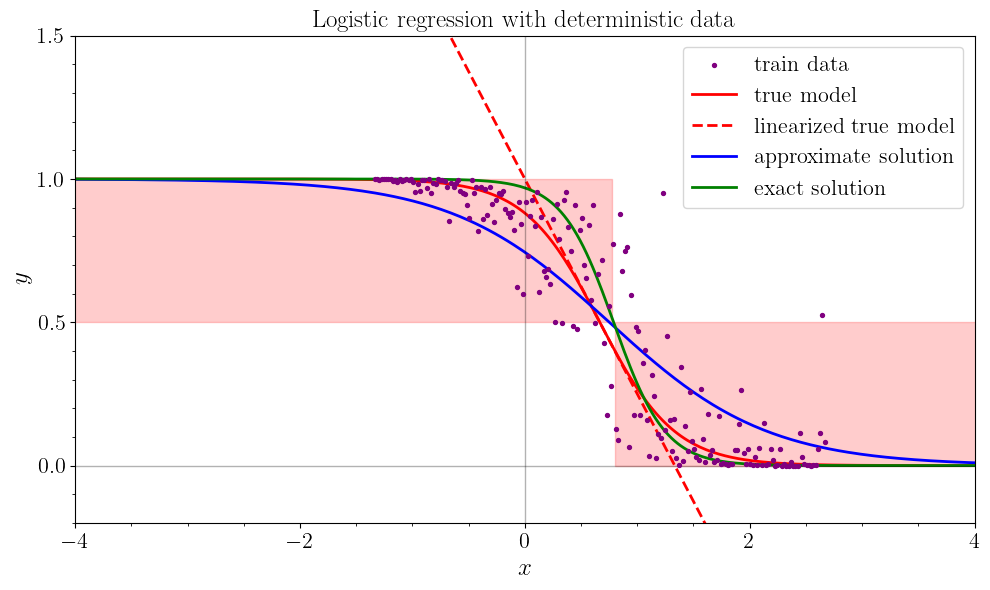

In [35]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, p(x_plot, omega_exact), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, H(decision_boundary - x_plot), 0.5, where=(H(decision_boundary - x_plot) < 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(decision_boundary - x_plot), where=(H(decision_boundary - x_plot) > 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_noise.pdf')
plt.show()

In [36]:
for t in np.arange(0, 1.1, 0.1):
    #ytrue = Y_train#Y_pred(p(x_train, omega_true, noise_std = 1), threshold=0.5)
    ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
    ypred = Y_pred(p(x_train, omega_approx, noise_std = 0), threshold=t)

    TP = np.sum((ypred == 1) & (ytrue == 1))
    FP = np.sum((ypred == 1) & (ytrue == 0))
    FN = np.sum((ypred == 0) & (ytrue == 1))
    TN = np.sum((ypred == 0) & (ytrue == 0))

    confusion_matrix = np.array([[TP, FP],
                                 [FN, TN]])
    
    if (TP + FN) > 0:
        TPR = TP / (TP + FN)
    else:
        TPR = 0.0  # or np.nan, depending on your preference

    if (FP + TN) > 0:
        FPR = FP / (FP + TN)
    else:
        FPR = 0.0  # or np.nan

    print("\n--------------------")
    print("Threshold:", t)
    print("[FPR,TPR]:", [FPR, TPR])    
    print("Confusion matrix: \n", confusion_matrix)


--------------------
Threshold: 0.0
[FPR,TPR]: [np.float64(1.0), np.float64(1.0)]
Confusion matrix: 
 [[100 100]
 [  0   0]]

--------------------
Threshold: 0.1
[FPR,TPR]: [np.float64(0.81), np.float64(1.0)]
Confusion matrix: 
 [[100  81]
 [  0  19]]

--------------------
Threshold: 0.2
[FPR,TPR]: [np.float64(0.52), np.float64(1.0)]
Confusion matrix: 
 [[100  52]
 [  0  48]]

--------------------
Threshold: 0.30000000000000004
[FPR,TPR]: [np.float64(0.33), np.float64(1.0)]
Confusion matrix: 
 [[100  33]
 [  0  67]]

--------------------
Threshold: 0.4
[FPR,TPR]: [np.float64(0.18), np.float64(1.0)]
Confusion matrix: 
 [[100  18]
 [  0  82]]

--------------------
Threshold: 0.5
[FPR,TPR]: [np.float64(0.04), np.float64(1.0)]
Confusion matrix: 
 [[100   4]
 [  0  96]]

--------------------
Threshold: 0.6000000000000001
[FPR,TPR]: [np.float64(0.0), np.float64(0.9)]
Confusion matrix: 
 [[ 90   0]
 [ 10 100]]

--------------------
Threshold: 0.7000000000000001
[FPR,TPR]: [np.float64(0.0), n

In [37]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

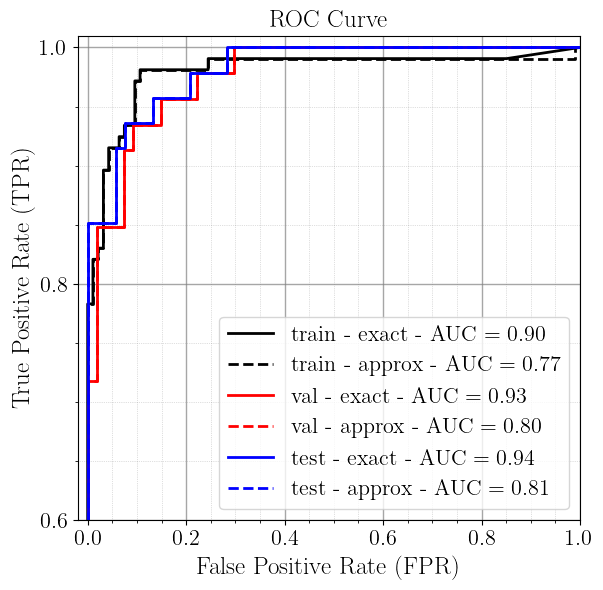

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_exact, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_exact, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_exact, p_test)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the aspect ratio to 1.
ax.set_aspect('auto')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Set the plot range.
ax.set_xlim(-0.02, 1.)
ax.set_ylim(0.6, 1.01)

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_noise_roc.pdf')

plt.show()

### Deterministic model (cubic data - linear model)

In [38]:
def poly(x: float, omega: np.ndarray) -> float:
    """Evaluates a polynomial with coefficients omega at x.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients of the polynomial.
        
    Returns
    -------
    float
        Polynomial value.
    """
    output = 0.0
    for i, omega_i in enumerate(omega):
        output += omega_i * x**i
    return output

def p(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [39]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [40]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true)
p_val = p(x_val, omega_true)
p_test = p(x_test, omega_true)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

In [41]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x)

Approximate omega: [ 0.87088715 -1.48633072]
Decision boundary (from approx solution) x = [2.8136065]


In [42]:
def Y_pred(p: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1/len(Y) * res

In [43]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, [0,0], method='BFGS')
omega_exact = result.x
omega_exact

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeW

array([ 204.27265404, -379.09291421])

In [44]:
loss_fn(X_train, p_train, omega_exact)

In [45]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 0.2570817261250602
Validation loss: 0.2546822107857419
Test loss: 0.2829658362139303


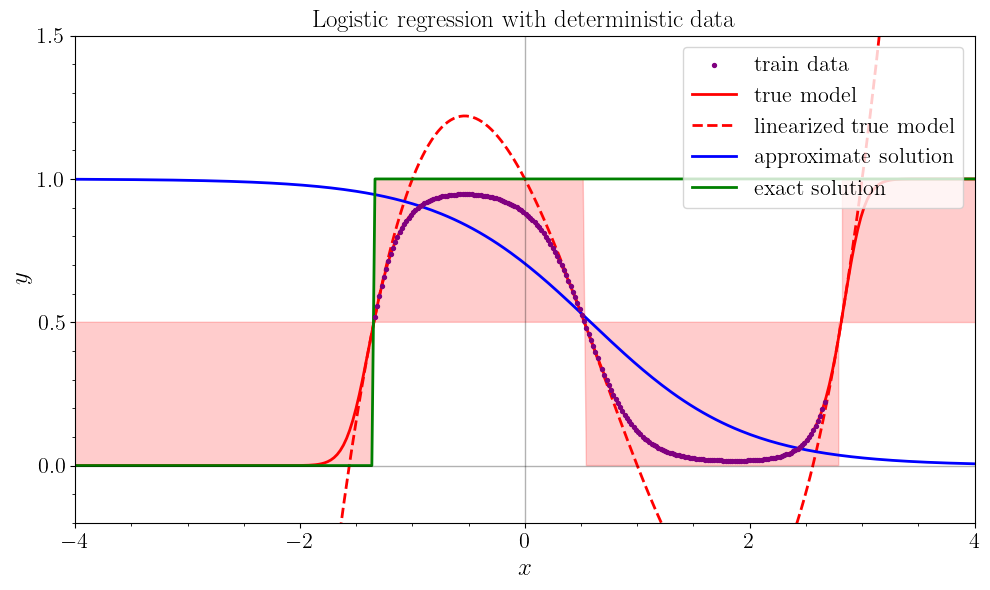

In [46]:
def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, H(x_plot - decision_boundary[0]), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
#ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]), where=(H(decision_boundary[0] - x_plot) > 0.5),
#                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)


# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

plt.show()

In [47]:
Y_pred(p_train, threshold=0.5)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [48]:
ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
ypred = Y_pred(p(x_train, omega_approx), threshold=0.5)

TP = np.sum((ypred == 1) & (ytrue == 1))
FP = np.sum((ypred == 1) & (ytrue == 0))
FN = np.sum((ypred == 0) & (ytrue == 1))
TN = np.sum((ypred == 0) & (ytrue == 0))

confusion_matrix = np.array([[TP, FP],
                             [FN, TN]])

print(confusion_matrix)

[[ 94   2]
 [  0 104]]


In [49]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

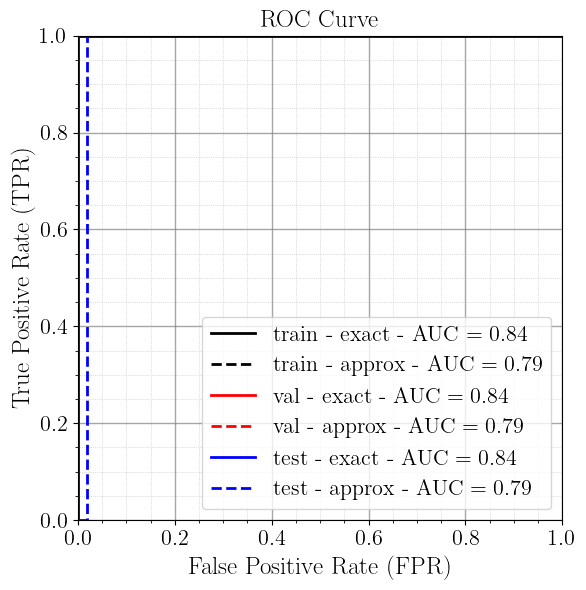

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_true, p_train)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_true, p_val)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_true, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the plot range.
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set the aspect ratio to 1.
ax.set_aspect('equal')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

plt.show()

### Probabilistic model (cubic data - linear model)

In [51]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [52]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [53]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true, noise_std = 0.5)
p_val = p(x_val, omega_true, noise_std = 0.5)
p_test = p(x_test, omega_true, noise_std = 0.5)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
print("Validation data for class 1:", np.count_nonzero(Y_val), "out of", len(Y_val))
print("Test data for class 1:", np.count_nonzero(Y_test), "out of", len(Y_test))

Train data for class 1: 102 out of 200
Validation data for class 1: 52 out of 100
Test data for class 1: 54 out of 100


In [54]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 0.94281267 -1.354219  ]
Decision boundary (from approx solution) x = 2.8136064975014605


In [55]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1/len(Y) * res

In [56]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, [0,0], method='BFGS')
omega_exact = result.x
print("Exact omega:", omega_exact)

Exact omega: [ 2.07728856 -2.93613302]


In [57]:
# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective_exact(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

Decision boundary x = [0.69620385]
Decision boundary (from approx solution) x = 0.707490318085104
Decision boundary x = [0.69620409]
Decision boundary (from approx solution) x = 0.7074918074558878
Decision boundary x = [0.69620265]
Decision boundary (from approx solution) x = 0.707494227525511


In [60]:
print("Approximate omega:", omega_approx)
print("Approximate decision boundary x =", result_approx.x[0])
print("Train loss - approximate omega:", loss_fn(X_train, p_train, omega_approx))
print("Validation loss - approximate omega:", loss_fn(X_val, p_val, omega_approx))
print("Test loss - approximate omega:", loss_fn(X_test, p_test, omega_approx))
print("\nExact omega:", omega_exact)
print("Exact decision boundary x =", result.x[0])
print("Train loss - exact omega:", loss_fn(X_train, p_train, omega_exact))
print("Validation loss - exact omega:", loss_fn(X_val, p_val, omega_exact))
print("Test loss - exact omega:", loss_fn(X_test, p_test, omega_exact))

Approximate omega: [ 0.94281267 -1.354219  ]
Approximate decision boundary x = 0.707494227525511
Train loss - approximate omega: 0.3394343512098105
Validation loss - approximate omega: 0.5348625730320467
Test loss - approximate omega: 0.5251018001815696

Exact omega: [ 2.07728856 -2.93613302]
Exact decision boundary x = 0.6962026501379439
Train loss - exact omega: 0.27296466913168244
Validation loss - exact omega: 0.6994410159409568
Test loss - exact omega: 0.6782265029346738


In [61]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 0.3394343512098105
Validation loss: 0.5348625730320467
Test loss: 0.5251018001815696


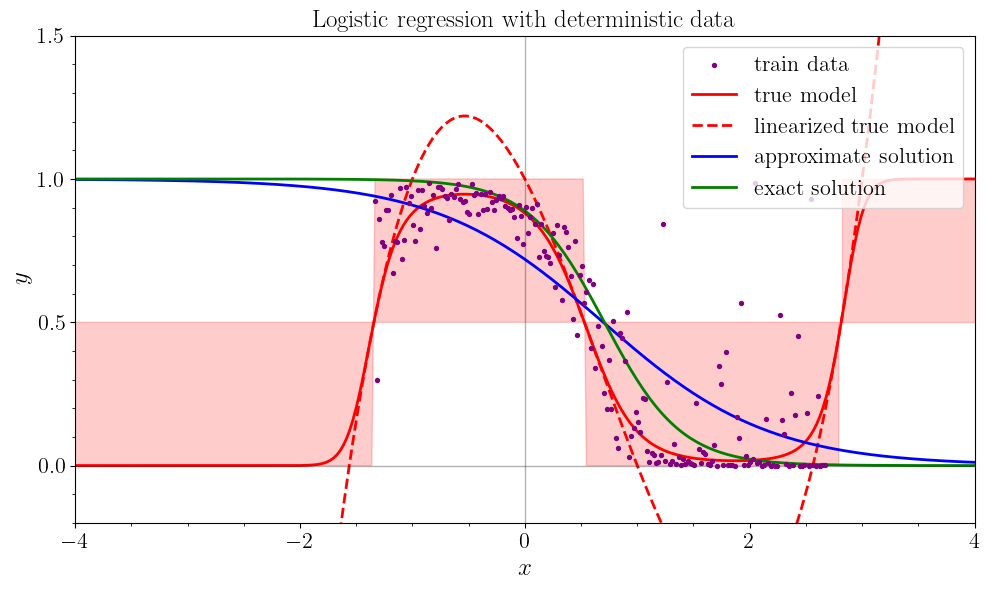

In [62]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, p(x_plot, omega_exact), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic.pdf')
plt.show()

In [63]:
for t in np.arange(0, 1.1, 0.1):
    #ytrue = Y_train#Y_pred(p(x_train, omega_true, noise_std = 1), threshold=0.5)
    ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
    ypred = Y_pred(p(x_train, omega_approx, noise_std = 0), threshold=t)

    TP = np.sum((ypred == 1) & (ytrue == 1))
    FP = np.sum((ypred == 1) & (ytrue == 0))
    FN = np.sum((ypred == 0) & (ytrue == 1))
    TN = np.sum((ypred == 0) & (ytrue == 0))

    confusion_matrix = np.array([[TP, FP],
                                 [FN, TN]])
    
    if (TP + FN) > 0:
        TPR = TP / (TP + FN)
    else:
        TPR = 0.0  # or np.nan, depending on your preference

    if (FP + TN) > 0:
        FPR = FP / (FP + TN)
    else:
        FPR = 0.0  # or np.nan

    print("\n--------------------")
    print("Threshold:", t)
    print("[FPR,TPR]:", [FPR, TPR])    
    print("Confusion matrix: \n", confusion_matrix)


--------------------
Threshold: 0.0
[FPR,TPR]: [np.float64(1.0), np.float64(1.0)]
Confusion matrix: 
 [[ 94 106]
 [  0   0]]

--------------------
Threshold: 0.1
[FPR,TPR]: [np.float64(0.8301886792452831), np.float64(1.0)]
Confusion matrix: 
 [[94 88]
 [ 0 18]]

--------------------
Threshold: 0.2
[FPR,TPR]: [np.float64(0.5471698113207547), np.float64(1.0)]
Confusion matrix: 
 [[94 58]
 [ 0 48]]

--------------------
Threshold: 0.30000000000000004
[FPR,TPR]: [np.float64(0.3584905660377358), np.float64(1.0)]
Confusion matrix: 
 [[94 38]
 [ 0 68]]

--------------------
Threshold: 0.4
[FPR,TPR]: [np.float64(0.20754716981132076), np.float64(1.0)]
Confusion matrix: 
 [[94 22]
 [ 0 84]]

--------------------
Threshold: 0.5
[FPR,TPR]: [np.float64(0.0660377358490566), np.float64(1.0)]
Confusion matrix: 
 [[94  7]
 [ 0 99]]

--------------------
Threshold: 0.6000000000000001
[FPR,TPR]: [np.float64(0.0), np.float64(0.925531914893617)]
Confusion matrix: 
 [[ 87   0]
 [  7 106]]

----------------

In [64]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

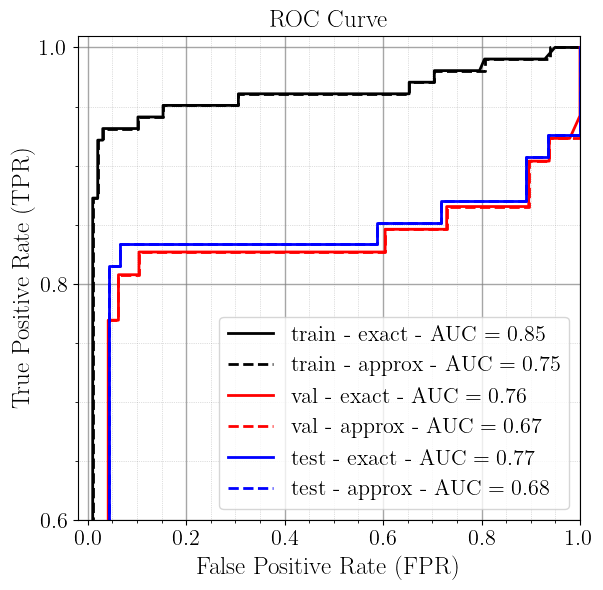

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_exact, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_exact, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_exact, p_test)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the aspect ratio to 1.
ax.set_aspect('auto')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Set the plot range.
ax.set_xlim(-0.02, 1.)
ax.set_ylim(0.6, 1.01)

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic_roc.pdf')

plt.show()

### Deterministic model (cubic data - cubic model)

In [67]:
def poly(x: float, omega: np.ndarray) -> float:
    """Evaluates a polynomial with coefficients omega at x.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients of the polynomial.
        
    Returns
    -------
    float
        Polynomial value.
    """
    output = 0.0
    for i, omega_i in enumerate(omega):
        output += omega_i * x**i
    return output

def p(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, omega: np.ndarray) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [68]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [69]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 3)
X_val = design_matrix(x_val, 3)
X_test = design_matrix(x_test, 3)

p_train = p(x_train, omega_true)
p_val = p(x_val, omega_true)
p_test = p(x_test, omega_true)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

In [70]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x)

Approximate omega: [ 1.4628086  -2.20812321 -0.93922233  0.52540746]
Decision boundary (from approx solution) x = [2.8136065]


In [81]:
def Y_pred(p: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1/len(Y) * res

In [82]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x
omega_exact

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_96414/1111959388.py:39: RuntimeW

array([ 1.01770998e+02, -1.40317645e+02,  4.87705522e-02, -1.72694660e+02])

In [83]:
loss_fn(X_train, p_train, omega_true)

In [84]:
loss_fn(X_train, p_train, omega_exact)

In [85]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 0.20024850111707096
Validation loss: 0.20035929034398833
Test loss: 0.21178105027159688


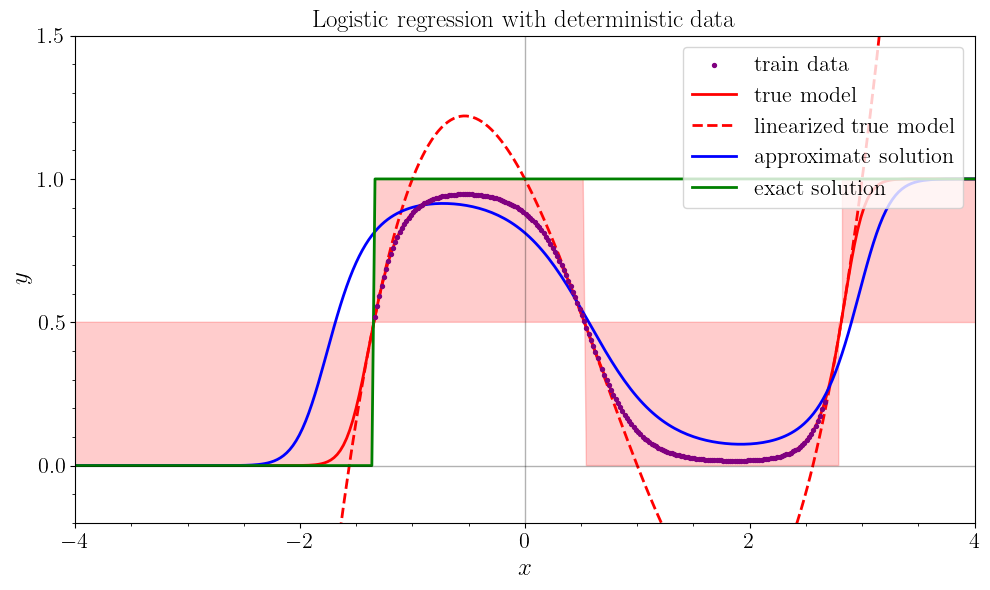

In [86]:
def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, H(x_plot - decision_boundary[0]), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
#ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]), where=(H(decision_boundary[0] - x_plot) > 0.5),
#                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)


# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

plt.show()

In [87]:
Y_pred(p_train, threshold=0.5)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [88]:
ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
ypred = Y_pred(p(x_train, omega_approx), threshold=0.5)

TP = np.sum((ypred == 1) & (ytrue == 1))
FP = np.sum((ypred == 1) & (ytrue == 0))
FN = np.sum((ypred == 0) & (ytrue == 1))
TN = np.sum((ypred == 0) & (ytrue == 0))

confusion_matrix = np.array([[TP, FP],
                             [FN, TN]])

print(confusion_matrix)

[[ 94   2]
 [  0 104]]


In [89]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

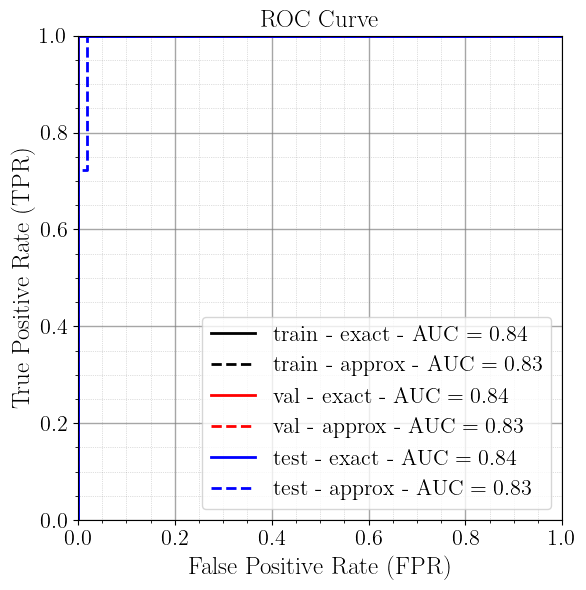

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_true, p_train)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_true, p_val)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_true, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the plot range.
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set the aspect ratio to 1.
ax.set_aspect('equal')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_roc.pdf')

plt.show()

### Probabilistic model (cubic data - cubic model)

In [91]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [92]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [94]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 3)
X_val = design_matrix(x_val, 3)
X_test = design_matrix(x_test, 3)

p_train = p(x_train, omega_true, noise_std = 0.5)
p_val = p(x_val, omega_true, noise_std = 0.5)
p_test = p(x_test, omega_true, noise_std = 0.5)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
print("Validation data for class 1:", np.count_nonzero(Y_val), "out of", len(Y_val))
print("Test data for class 1:", np.count_nonzero(Y_test), "out of", len(Y_test))

Train data for class 1: 102 out of 200
Validation data for class 1: 52 out of 100
Test data for class 1: 54 out of 100


In [95]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 1.62370132 -2.01177318 -1.04910373  0.54730383]
Decision boundary (from approx solution) x = 2.8136064975014605


In [97]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1/len(Y) * res

In [98]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x
print("Exact omega:", omega_exact)

Exact omega: [ 3.64782879 -4.4071383  -2.44061812  1.30511994]


In [99]:
# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective_exact(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

Decision boundary x = [-1.58453672]
Decision boundary (from approx solution) x = -1.53025515235477
Decision boundary x = [0.65861607]
Decision boundary (from approx solution) x = 0.6686458549491349
Decision boundary x = [2.84277862]
Decision boundary (from approx solution) x = 2.731642640450329


In [101]:
print("Approximate omega:", omega_approx)
print("Train loss - approximate omega:", loss_fn(X_train, p_train, omega_approx))
print("Validation loss - approximate omega:", loss_fn(X_val, p_val, omega_approx))
print("Test loss - approximate omega:", loss_fn(X_test, p_test, omega_approx))
print("\nExact omega:", omega_exact)
print("Train loss - exact omega:", loss_fn(X_train, p_train, omega_exact))
print("Validation loss - exact omega:", loss_fn(X_val, p_val, omega_exact))
print("Test loss - exact omega:", loss_fn(X_test, p_test, omega_exact))

Approximate omega: [ 1.62370132 -2.01177318 -1.04910373  0.54730383]
Train loss - approximate omega: 0.2777910479009492
Validation loss - approximate omega: 0.40083312189370257
Test loss - approximate omega: 0.3998138720505483

Exact omega: [ 3.64782879 -4.4071383  -2.44061812  1.30511994]
Train loss - exact omega: 0.20859876915411776
Validation loss - exact omega: 0.424648075738709
Test loss - exact omega: 0.42481082996596314


In [63]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 55.55820958018984
Validation loss: 40.083312189370254
Test loss: 39.98138720505483


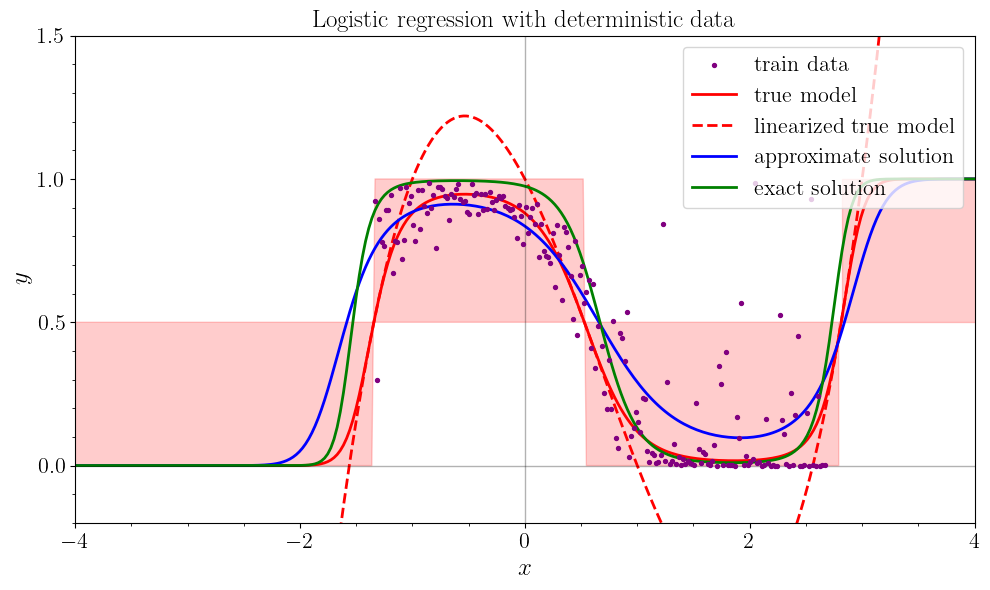

In [64]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, p(x_plot, omega_exact), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic2.pdf')
plt.show()

In [65]:
for t in np.arange(0, 1.1, 0.1):
    #ytrue = Y_train#Y_pred(p(x_train, omega_true, noise_std = 1), threshold=0.5)
    ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
    ypred = Y_pred(p(x_train, omega_approx, noise_std = 0), threshold=t)

    TP = np.sum((ypred == 1) & (ytrue == 1))
    FP = np.sum((ypred == 1) & (ytrue == 0))
    FN = np.sum((ypred == 0) & (ytrue == 1))
    TN = np.sum((ypred == 0) & (ytrue == 0))

    confusion_matrix = np.array([[TP, FP],
                                 [FN, TN]])
    
    if (TP + FN) > 0:
        TPR = TP / (TP + FN)
    else:
        TPR = 0.0  # or np.nan, depending on your preference

    if (FP + TN) > 0:
        FPR = FP / (FP + TN)
    else:
        FPR = 0.0  # or np.nan

    print("\n--------------------")
    print("Threshold:", t)
    print("[FPR,TPR]:", [FPR, TPR])    
    print("Confusion matrix: \n", confusion_matrix)


--------------------
Threshold: 0.0
[FPR,TPR]: [np.float64(1.0), np.float64(1.0)]
Confusion matrix: 
 [[ 94 106]
 [  0   0]]

--------------------
Threshold: 0.1
[FPR,TPR]: [np.float64(0.8773584905660378), np.float64(1.0)]
Confusion matrix: 
 [[94 93]
 [ 0 13]]

--------------------
Threshold: 0.2
[FPR,TPR]: [np.float64(0.3867924528301887), np.float64(1.0)]
Confusion matrix: 
 [[94 41]
 [ 0 65]]

--------------------
Threshold: 0.30000000000000004
[FPR,TPR]: [np.float64(0.20754716981132076), np.float64(1.0)]
Confusion matrix: 
 [[94 22]
 [ 0 84]]

--------------------
Threshold: 0.4
[FPR,TPR]: [np.float64(0.12264150943396226), np.float64(1.0)]
Confusion matrix: 
 [[94 13]
 [ 0 93]]

--------------------
Threshold: 0.5
[FPR,TPR]: [np.float64(0.05660377358490566), np.float64(1.0)]
Confusion matrix: 
 [[ 94   6]
 [  0 100]]

--------------------
Threshold: 0.6000000000000001
[FPR,TPR]: [np.float64(0.0), np.float64(0.9893617021276596)]
Confusion matrix: 
 [[ 93   0]
 [  1 106]]

---------

In [66]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

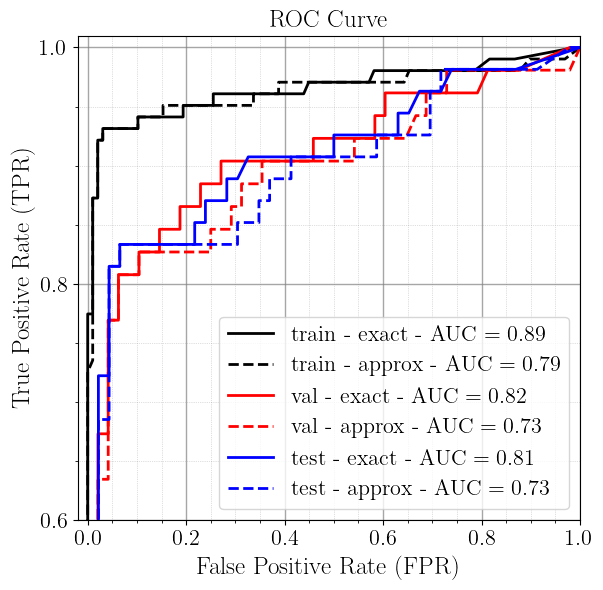

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_exact, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_exact, p_val)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_exact, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the aspect ratio to 1.
ax.set_aspect('auto')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Set the plot range.
ax.set_xlim(-0.02, 1.)
ax.set_ylim(0.6, 1.01)

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic2_roc.pdf')

plt.show()

### Probabilistic model with L2 (cubic data - cubic model)

In [102]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [103]:
# Define the true parameters
omega_true = np.array([2, -3, -2, 1])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

decision_boundary = []

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])
decision_boundary.append(result.x[0])

Decision boundary x = [-1.34292303]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [0.52931647]
Decision boundary (from approx solution) x = -1.342923012576254
Decision boundary x = [2.8136065]
Decision boundary (from approx solution) x = -1.342923012576254


In [104]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 3)
X_val = design_matrix(x_val, 3)
X_test = design_matrix(x_test, 3)

p_train = p(x_train, omega_true, noise_std = 0.5)
p_val = p(x_val, omega_true, noise_std = 0.5)
p_test = p(x_test, omega_true, noise_std = 0.5)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
print("Validation data for class 1:", np.count_nonzero(Y_val), "out of", len(Y_val))
print("Test data for class 1:", np.count_nonzero(Y_test), "out of", len(Y_test))

Train data for class 1: 102 out of 200
Validation data for class 1: 52 out of 100
Test data for class 1: 54 out of 100


In [105]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 1.62370132 -2.01177318 -1.04910373  0.54730383]
Decision boundary (from approx solution) x = 2.8136064975014605


In [107]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5,
            l2: float = 0.
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1/len(Y) * res + l2 * np.linalg.norm(omega)**2

In [140]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega, threshold = 0.5, l2 = 0.05)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x
print("Exact omega:", omega_exact)

Exact omega: [ 0.62825841 -0.81924982 -0.0949609  -0.15281422]


In [141]:
# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective_exact(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([-2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

# Initial guess for x (e.g., 0)
initial_x = np.array([2.0])
result = minimize(objective_exact, initial_x, args=(omega_approx,), method='BFGS')
result_approx = minimize(objective_exact, initial_x, args=(omega_exact,), method='BFGS')
print("Decision boundary x =", result.x)
print("Decision boundary (from approx solution) x =", result_approx.x[0])

Decision boundary x = [-1.58453672]
Decision boundary (from approx solution) x = 0.6619691922908439
Decision boundary x = [0.65861607]
Decision boundary (from approx solution) x = 0.6619669222421793
Decision boundary x = [2.84277862]
Decision boundary (from approx solution) x = 0.6619532092885364


In [142]:
print("Approximate omega:", omega_approx)
print("Train loss - approximate omega:", loss_fn(X_train, p_train, omega_approx))
print("Validation loss - approximate omega:", loss_fn(X_val, p_val, omega_approx))
print("Test loss - approximate omega:", loss_fn(X_test, p_test, omega_approx))
print("\nExact omega:", omega_exact)
print("Train loss - exact omega:", loss_fn(X_train, p_train, omega_exact))
print("Validation loss - exact omega:", loss_fn(X_val, p_val, omega_exact))
print("Test loss - exact omega:", loss_fn(X_test, p_test, omega_exact))

Approximate omega: [ 1.62370132 -2.01177318 -1.04910373  0.54730383]
Train loss - approximate omega: 0.2777910479009492
Validation loss - approximate omega: 0.40083312189370257
Test loss - approximate omega: 0.3998138720505483

Exact omega: [ 0.62825841 -0.81924982 -0.0949609  -0.15281422]
Train loss - exact omega: 0.3796305867578279
Validation loss - exact omega: 0.6832734823615253
Test loss - exact omega: 0.6635486073089208


In [123]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 0.2777910479009492
Validation loss: 0.40083312189370257
Test loss: 0.3998138720505483


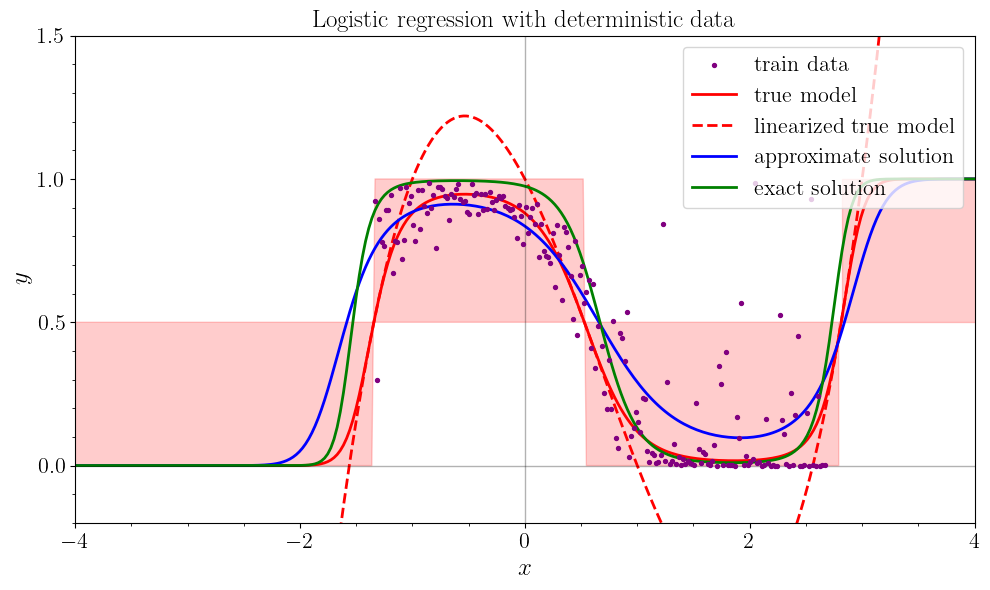

In [ ]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, p(x_plot, omega_exact), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[0]) - H(x_plot - decision_boundary[1]) + H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) > 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(x_plot - decision_boundary[2]), where=(H(decision_boundary[2] - x_plot) < 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic2.pdf')
plt.show()

In [ ]:
for t in np.arange(0, 1.1, 0.1):
    #ytrue = Y_train#Y_pred(p(x_train, omega_true, noise_std = 1), threshold=0.5)
    ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
    ypred = Y_pred(p(x_train, omega_approx, noise_std = 0), threshold=t)

    TP = np.sum((ypred == 1) & (ytrue == 1))
    FP = np.sum((ypred == 1) & (ytrue == 0))
    FN = np.sum((ypred == 0) & (ytrue == 1))
    TN = np.sum((ypred == 0) & (ytrue == 0))

    confusion_matrix = np.array([[TP, FP],
                                 [FN, TN]])
    
    if (TP + FN) > 0:
        TPR = TP / (TP + FN)
    else:
        TPR = 0.0  # or np.nan, depending on your preference

    if (FP + TN) > 0:
        FPR = FP / (FP + TN)
    else:
        FPR = 0.0  # or np.nan

    print("\n--------------------")
    print("Threshold:", t)
    print("[FPR,TPR]:", [FPR, TPR])    
    print("Confusion matrix: \n", confusion_matrix)


--------------------
Threshold: 0.0
[FPR,TPR]: [np.float64(1.0), np.float64(1.0)]
Confusion matrix: 
 [[ 94 106]
 [  0   0]]

--------------------
Threshold: 0.1
[FPR,TPR]: [np.float64(0.8773584905660378), np.float64(1.0)]
Confusion matrix: 
 [[94 93]
 [ 0 13]]

--------------------
Threshold: 0.2
[FPR,TPR]: [np.float64(0.3867924528301887), np.float64(1.0)]
Confusion matrix: 
 [[94 41]
 [ 0 65]]

--------------------
Threshold: 0.30000000000000004
[FPR,TPR]: [np.float64(0.20754716981132076), np.float64(1.0)]
Confusion matrix: 
 [[94 22]
 [ 0 84]]

--------------------
Threshold: 0.4
[FPR,TPR]: [np.float64(0.12264150943396226), np.float64(1.0)]
Confusion matrix: 
 [[94 13]
 [ 0 93]]

--------------------
Threshold: 0.5
[FPR,TPR]: [np.float64(0.05660377358490566), np.float64(1.0)]
Confusion matrix: 
 [[ 94   6]
 [  0 100]]

--------------------
Threshold: 0.6000000000000001
[FPR,TPR]: [np.float64(0.0), np.float64(0.9893617021276596)]
Confusion matrix: 
 [[ 93   0]
 [  1 106]]

---------

In [ ]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

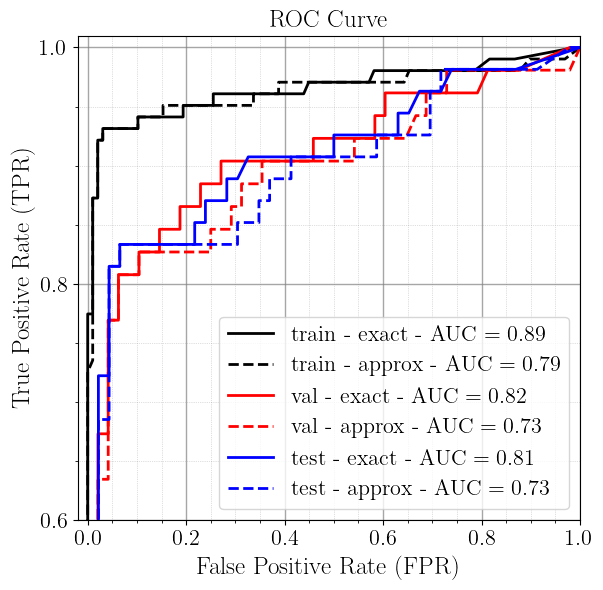

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_exact, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_exact, p_val)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_exact, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the aspect ratio to 1.
ax.set_aspect('auto')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Set the plot range.
ax.set_xlim(-0.02, 1.)
ax.set_ylim(0.6, 1.01)

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_cubic2_roc.pdf')

plt.show()

### Class imbalance (linear data - linear model)

In [114]:
def poly(x: np.ndarray, 
         omega: np.ndarray, 
         noise_std: float = 0.
        ) -> np.ndarray:
    """
    Evaluates a polynomial with coefficients omega at x, adding independent Gaussian noise 
    to each coefficient for each data point.
    
    Parameters
    ----------
    x : np.ndarray
        Input values. Can be a scalar or a 1D numpy array.
    omega : np.ndarray
        Coefficients of the polynomial.
    noise_std : float, optional
        Standard deviation of the Gaussian noise added to each coefficient, by default 1.
        
    Returns
    -------
    np.ndarray or float
        The output of the polynomial function evaluated at each x, with independent noise for each data point.
    """
    np.random.seed(0)
    # Ensure x is an array.
    x = np.atleast_1d(x)
    # Number of coefficients.
    k = len(omega)
    # For each coefficient, compute the corresponding powers of x: this creates a (k, len(x)) array.
    powers = np.array([x**i for i in range(k)])
    # Generate independent noise for each coefficient and each data point.
    noise = np.random.normal(0, noise_std, size=powers.shape)
    # Add noise to the coefficients and multiply elementwise by the power of x.
    effective_terms = (omega.reshape(-1, 1) + noise) * powers
    # Sum over the coefficients (axis 0) to get the final result.
    result = effective_terms.sum(axis=0)
    # If x was originally a scalar, return a scalar.
    if result.size == 1:
        return result.item()
    return result

def p(x: float, 
      omega: np.ndarray,
      noise_std: float = 0.
      ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1.0 / (1.0 + np.exp(-poly_val))

def p_approx(x: float, 
             omega: np.ndarray,
             noise_std: float = 0.
             ) -> float:
    """Computes the logistic function output given x and coefficients omega.
    
    Parameters
    ----------
    x : float
        Input value.
    omega : np.ndarray
        Coefficients for the polynomial inside the logistic function.
    
    Returns
    -------
    float
        Logistic function value.
    """
    poly_val = poly(x, omega, noise_std)
    return 1./2 + poly_val/4.

def design_matrix(x: np.ndarray, degree: int) -> np.ndarray:
    """Computes the design matrix for a polynomial of a given degree.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    degree : int
        Degree of the polynomial.
    
    Returns
    -------
    np.ndarray
        Design matrix.
    """
    X = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        X[:, i] = x**i
    return X

In [106]:
# Define the true parameters
omega_true = np.array([2, -3])

# Define the objective: squared difference between y(x,omega_true) and 0.5.
def objective(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p(x_scalar, omega) - 0.5)**2

# Define the approximate objective: squared difference between y_approx(x,omega_true) and 0.5.
def objective_approx(x, omega):
    # x comes as an array of one element; extract the scalar.
    x_scalar = x[0]
    return (p_approx(x_scalar, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary x =", result.x[0])
print("Objective value =", result.fun)
decision_boundary = result.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.6666669622623926
Objective value = 4.914946870639898e-14
Decision boundary (from approx solution) x = 0.6666666593080686
Objective value (from approx solution) = 3.0458793996399694e-17


In [108]:
def Y_pred(p: np.ndarray, 
           threshold: float = 0.5
          ) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return (p >= threshold).astype(int)#np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5
           ) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1 * res

In [130]:
Y_train

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [131]:
Y_pred(p_train, 0.5)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [147]:
res = []
for i in np.array(range(0,200)):
    # Generate data coordinates
    x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 1+i),(2/3) + 0.02 * np.arange(1, 201-i))))
    X_train = design_matrix(x_train, 1)
    p_train = p(x_train, omega_true, noise_std=0.1)
    Y_train = Y_pred(p_train, 0.5)
    #print("Train data for class 1:", np.count_nonzero(Y_train), "out of", len(Y_train))
    
    omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
    # Minimize the loss function and extract omega
    objective = lambda omega: loss_fn(X_train, p_train, omega)
    result = minimize(objective, [0,0])
    omega_exact = result.x
    #print("Exact omega:", omega_exact)

    # Define the objective to determine the decision boundary
    def objective_exact(x, omega):
        # x comes as an array of one element; extract the scalar.
        x_scalar = x[0]
        return (p(x_scalar, omega) - 0.5)**2

    # Initial guess for x (e.g., 0)
    initial_x = np.array([decision_boundary])
    # Optimize using minimize; here we pass omega_true as an extra argument.
    result_approx = minimize(objective_exact, initial_x, args=(omega_approx,))
    # Optimize using minimize; here we pass omega_true as an extra argument.
    result_exact = minimize(objective_exact, initial_x, args=(omega_exact,))

    decision_boundary_exact = result_exact.x[0]
    #print("Decision boundary x =", decision_boundary_exact)

    decision_boundary_approx = result_approx.x[0]
    #print("Decision boundary (from approx solution) x =", decision_boundary_approx)
    
    res.append([np.count_nonzero(Y_train), np.count_nonzero(Y_train)/len(Y_train), decision_boundary_exact, decision_boundary_approx])
    
res = np.array(res)

/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_36213/1935800102.py:42: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_36213/1935800102.py:42: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/8p/lb_zz6bs7g7cdkt7y_yjy0z40000gn/T/ipykernel_36213/1935800102.py:42: RuntimeWarning: overflow encountered in exp
  res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
/opt/anaconda3/envs/tf_torch_env/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:59

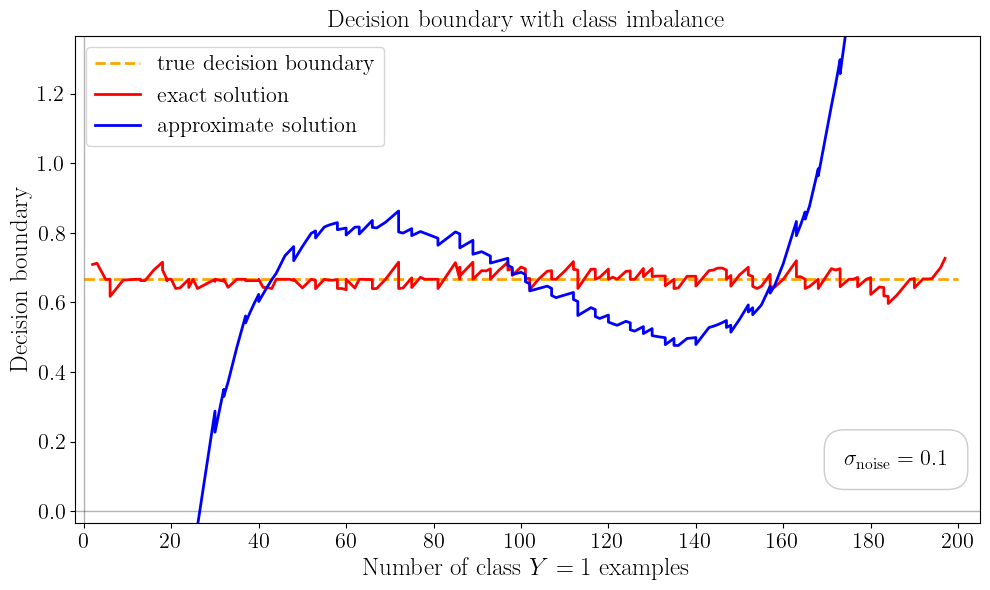

In [160]:
# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# Plot the decision boundary as a function of the number of data points
fig, ax = plt.subplots(figsize=(10, 6))

plt.text(
            0.85, 0.15,
            r'$\sigma_{\text{noise}} = 0.1$',
            transform=plt.gca().transAxes,  # Use axis coordinates (0,0) lower left, (1,1) upper right
            horizontalalignment='left',     # Align text to the right edge of the box
            verticalalignment='top',         # Align text to the top edge of the box
            fontsize=16,
            color='black',
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.4, boxstyle='round,pad=0.9')
)

# Plot the decision boundary as a function of the number of data points
ax.plot([0,200], [decision_boundary,decision_boundary], color='orange', linewidth=2, linestyle="--", label=r'$\text{true decision boundary}$')
ax.plot(res[:-3,0], res[:-3,2], color='red', linewidth=2, label=r'$\text{exact solution}$')
ax.plot(res[:-3,0], res[:-3,3], color='blue', linewidth=2, label=r'$\text{approximate solution}$')

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Decision boundary with class imbalance', fontsize = 18)
ax.set_xticks(np.array(range(-20,205,20)))
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xlabel(r'$\text{Number of class }Y=1\text{ examples}$', fontsize=18)
ax.set_ylabel(r'$\text{Decision boundary}$', fontsize=18)
ax.legend(loc='upper left', fontsize=16)
ax.set_xlim(-2,205)
ax.set_ylim(decision_boundary-0.7,decision_boundary+0.7)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_imbalance.pdf')
plt.show()


## TensorFlow2 (to be completed)

### Deterministic model (linear data - linear model)

In [174]:
import tensorflow as tf

def poly_tf(x: tf.Tensor, omega: tf.Tensor) -> tf.Tensor:
    """
    Evaluates a polynomial with coefficients omega at x.

    Parameters
    ----------
    x : tf.Tensor
        Input value (scalar or tensor).
    omega : tf.Tensor
        1D tensor of polynomial coefficients.

    Returns
    -------
    tf.Tensor
        Polynomial value.
    """
    # Assume omega has a static shape (i.e., omega.shape[0] is an integer).
    n = omega.shape[0]
    # Build the list of terms: omega[i] * x^i for i in range(n)
    terms = [omega[i] * tf.pow(x, i) for i in range(n)]
    return tf.add_n(terms)

def p_tf(x: tf.Tensor, omega: tf.Tensor) -> tf.Tensor:
    """
    Computes the logistic function output given x and coefficients omega.

    Parameters
    ----------
    x : tf.Tensor
        Input value.
    omega : tf.Tensor
        Coefficients for the polynomial inside the logistic function.

    Returns
    -------
    tf.Tensor
        Logistic function value.
    """
    poly_val = poly_tf(x, omega)
    # Clip poly_val to a safe range (e.g., between -50 and 50)
    poly_val = tf.clip_by_value(poly_val, -50.0, 50.0)
    return 1.0 / (1.0 + tf.exp(-poly_val))

def p_approx_tf(x: tf.Tensor, omega: tf.Tensor) -> tf.Tensor:
    """
    Computes an approximate logistic function output given x and coefficients omega.

    Parameters
    ----------
    x : tf.Tensor
        Input value.
    omega : tf.Tensor
        Coefficients for the polynomial.

    Returns
    -------
    tf.Tensor
        Approximate logistic function value.
    """
    poly_val = poly_tf(x, omega)
    return 0.5 + poly_val / 4.0

def design_matrix_tf(x: tf.Tensor, degree: int) -> tf.Tensor:
    """
    Computes the design matrix for a polynomial of a given degree.

    Parameters
    ----------
    x : tf.Tensor
        1D tensor of input values.
    degree : int
        Degree of the polynomial.

    Returns
    -------
    tf.Tensor
        Design matrix of shape [len(x), degree+1], where the i-th column is x^i.
    """
    # Create a list of tensors: x^0, x^1, ..., x^degree.
    powers = [tf.pow(x, i) for i in range(degree + 1)]
    # Stack these along axis 1 to get a 2D tensor.
    X = tf.stack(powers, axis=1)
    return X

# Example usage:
# Define some example values.
x_val = tf.constant(2.0, dtype=tf.float64)  # a scalar input
omega_true = tf.constant([2.0, -3.0], dtype=tf.float64)  # for example, a linear polynomial

# Compute the polynomial value
print("poly_tf(2, omega_true) =", poly_tf(x_val, omega_true).numpy())
print("p_tf(2, omega_true) =", p_tf(x_val, omega_true).numpy())
print("p_approx_tf(2, omega_true) =", p_approx_tf(x_val, omega_true).numpy())

# Design matrix for x values (vector input)
x_array = tf.constant(np.arange(-3, 4, 1), dtype=tf.float64)
X_design = design_matrix_tf(x_array, degree=3)
print("Design matrix:\n", X_design.numpy())

poly_tf(2, omega_true) = -4.0
p_tf(2, omega_true) = 0.01798620996209156
p_approx_tf(2, omega_true) = -0.5
Design matrix:
 [[  1.  -3.   9. -27.]
 [  1.  -2.   4.  -8.]
 [  1.  -1.   1.  -1.]
 [  1.   0.   0.   0.]
 [  1.   1.   1.   1.]
 [  1.   2.   4.   8.]
 [  1.   3.   9.  27.]]


In [176]:
# Define true parameters.
omega_true = tf.constant([2.0, -3.0], dtype=tf.float64)

# Create a scalar variable for x.
x_var = tf.Variable(0.0, dtype=tf.float64)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)  # Try a lower learning rate

num_iterations = 2000

for i in range(num_iterations):
    with tf.GradientTape() as tape:
        loss_val = objective(x_var, omega_true)
    grads = tape.gradient(loss_val, [x_var])
    optimizer.apply_gradients(zip(grads, [x_var]))
    
    # Optionally, check for NaNs and print progress.
    if tf.math.is_nan(loss_val):
        print(f"NaN encountered at iteration {i}")
        break
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss_val.numpy():.6f}, x = {x_var.numpy():.6f}")

decision_boundary = x_var.numpy()
print("Decision boundary x =", decision_boundary)
print("Objective value =", loss_val.numpy())

# Similarly for the approximate model:
x_var_approx = tf.Variable(0.0, dtype=tf.float64)
optimizer_approx = tf.keras.optimizers.Adam(learning_rate=0.01)
for i in range(num_iterations):
    with tf.GradientTape() as tape:
        loss_approx = objective_approx(x_var_approx, omega_true)
    grads_approx = tape.gradient(loss_approx, [x_var_approx])
    optimizer_approx.apply_gradients(zip(grads_approx, [x_var_approx]))
    
    if tf.math.is_nan(loss_approx):
        print(f"NaN encountered in approximate objective at iteration {i}")
        break
    if i % 100 == 0:
        print(f"Iteration {i} (approx): Loss = {loss_approx.numpy():.6f}, x = {x_var_approx.numpy():.6f}")

decision_boundary_approx = x_var_approx.numpy()
print("Decision boundary (approx) x =", decision_boundary_approx)
print("Objective value (approx) =", loss_approx.numpy())

Iteration 0: Loss = 0.145006, x = nan
NaN encountered at iteration 1
Decision boundary x = nan
Objective value = nan
Iteration 0 (approx): Loss = 0.250000, x = nan
NaN encountered in approximate objective at iteration 1
Decision boundary (approx) x = nan
Objective value (approx) = nan


In [ ]:
## --- Define the true parameters ---
omega_true = tf.constant([2.0, -3.0], dtype=tf.float64)

# --- Define the objective functions ---
def objective(x, omega):
    # x is a scalar variable (tf.Tensor)
    return (p_tf(x, omega) - 0.5)**2

def objective_approx(x, omega):
    return (p_approx_tf(x, omega) - 0.5)**2

# Initial guess for x (e.g., 0)
initial_x = np.array([0.0])

# Optimize using minimize; here we pass omega_true as an extra argument.
result = minimize(objective, initial_x, args=(omega_true,), method='BFGS')

# Optimize using minimize; here we pass omega_true as an extra argument.
result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary x =", result.x[0])
print("Objective value =", result.fun)
decision_boundary = result.x[0]

print("Decision boundary (from approx solution) x =", result_approx.x[0])
print("Objective value (from approx solution) =", result_approx.fun)

Decision boundary x = 0.6666669622623926
Objective value = 4.914946870639898e-14
Decision boundary (from approx solution) x = 0.6666666593080686
Objective value (from approx solution) = 3.0458793996399694e-17


In [ ]:
# Generate data coordinates
x_train = np.sort(np.concatenate(((2/3) - 0.02 * np.arange(1, 101),(2/3) + 0.02 * np.arange(1, 101))))
x_val = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) + 0.03
x_test = np.sort(np.concatenate(((2/3) - 0.04 * np.arange(1, 51),(2/3) + 0.04 * np.arange(1, 51)))) - 0.03

X_train = design_matrix(x_train, 1)
X_val = design_matrix(x_val, 1)
X_test = design_matrix(x_test, 1)

p_train = p(x_train, omega_true)
p_val = p(x_val, omega_true)
p_test = p(x_test, omega_true)

Y_train = np.array([1 if p_i >= 0.5 else 0 for p_i in p_train])
Y_val = np.array([1 if p_i >= 0.5 else 0 for p_i in p_val])
Y_test = np.array([1 if p_i >= 0.5 else 0 for p_i in p_test])

In [ ]:
omega_approx = np.linalg.pinv(X_train.T @ X_train) @ (4 * X_train.T @ Y_train - 2 * X_train.T @ np.ones_like(Y_train))
print("Approximate omega:", omega_approx)

result_approx = minimize(objective_approx, initial_x, args=(omega_true,), method='BFGS')

print("Decision boundary (from approx solution) x =", result_approx.x[0])

Approximate omega: [ 0.99502488 -1.49253731]
Decision boundary (from approx solution) x = 0.6666666593080686


In [ ]:
def Y_pred(p: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """Converts probabilities to predictions using a threshold.
    
    Parameters
    ----------
    p : np.ndarray
        Probabilities.
    threshold : float
        Threshold for the conversion.
    
    Returns
    -------
    np.ndarray
        Predictions.
    """
    return np.array([1 if p_i > threshold else 0 for p_i in p])

def loss_fn(X: np.ndarray, 
            p: np.ndarray, 
            omega: np.ndarray,
            threshold: float = 0.5) -> float:
    """Computes the logistic loss for a given dataset and parameters.
    
    Parameters
    ----------
    X : np.ndarray
        Design matrix.
    Y : np.ndarray
        Target values.
    omega : np.ndarray
        Parameters.
    
    Returns
    -------
    float
        Logistic loss.
    """
    Y = Y_pred(p, threshold)
    res = X.T @ Y @ omega - np.sum(np.log(1 + np.exp(X @ omega)))
    return -1 * res

In [ ]:
# Minimize the loss function and extract omega
objective = lambda omega: loss_fn(X_train, p_train, omega)
result = minimize(objective, omega_true, method='BFGS')
omega_exact = result.x

In [ ]:
loss_fn(X_train, p_train, omega_true)

In [ ]:
loss_fn(X_train, p_train, omega_exact)

In [ ]:
train_loss = loss_fn(X_train, Y_train, omega_approx)
val_loss = loss_fn(X_val, Y_val, omega_approx)
test_loss = loss_fn(X_test, Y_test, omega_approx)
print("Train loss:", train_loss)
print("Validation loss:", val_loss)
print("Test loss:", test_loss)

Train loss: 51.11964133050873
Validation loss: 25.256239837580452
Test loss: 25.256239837580452


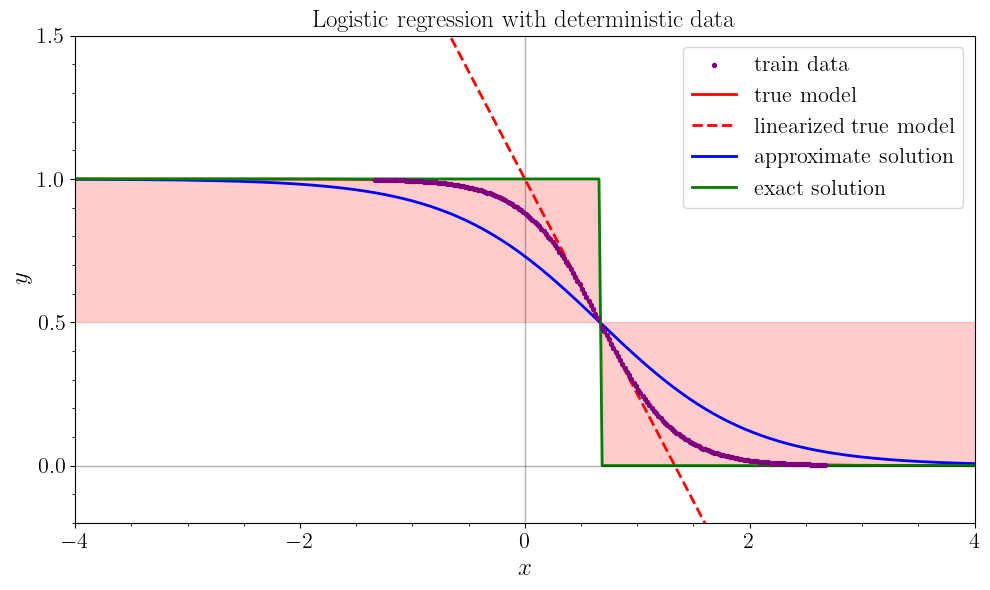

In [ ]:
save = True

def H(c: float) -> float:
    """Computes the entropy function H(c).
    
    Parameters
    ----------
    c : float
        Value of c.
    
    Returns
    -------
    float
    
        Entropy value.
    """
    return np.heaviside(c, 0.5)

# Enable LaTeX rendering for text
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"""\usepackage{amsmath}
\usepackage{amsfonts}
\usepackage{amssymb}
\usepackage{bm}"""

# --- Generate custom tick marks ---
x_major_ticks = np.arange(-10, 10+1, 2)
x_minor_ticks = np.arange(-10, 10+0.5, 0.5)
y_major_ticks = np.arange(-2, 2+0.5, 0.5)
y_minor_ticks = np.arange(-2, 2+0.1, 0.1)

# --- Define plotting range and decision boundary ---
x_plot = np.linspace(-7, 7, 500)

# --- Create the main plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot training data ---
# Assume x_train and p_train are numpy arrays. For demonstration, we create dummy data:
ax.scatter(x_train, p_train, color='purple', s=8, zorder=5, label=r'$\text{train data}$')

# Plot the various curves with styles similar to your Mathematica code:
ax.plot(x_plot, p(x_plot,omega_true), color='red', linewidth=2, label=r'$\text{true model}$')
ax.plot(x_plot, p_approx(x_plot,omega_true), color='red', linestyle='--', linewidth=2, label=r'$\text{linearized true model}$')
ax.plot(x_plot, p(x_plot, omega_approx), color='blue', linewidth=2, label=r'$\text{approximate solution}$')
ax.plot(x_plot, H(decision_boundary - x_plot), color='green', linewidth=2, label=r'$\text{exact solution}$')
# The constant 0.5 curve (with zero opacity) is included for filling purposes:
ax.plot(x_plot, 0.5*np.ones_like(x_plot), color='black', alpha=0, linewidth=2)

# Fill between the constant 0.5 and the Heaviside curve.
# In Mathematica, you filled curve 5 -> 4 and 4 -> 5.
# Here, we assume we want to fill between heaviside(db - x) and 0.5.
# Choose the fill condition appropriately. Here, we fill where heaviside < 0.5.
ax.fill_between(x_plot, H(decision_boundary - x_plot), 0.5, where=(H(decision_boundary - x_plot) < 0.5),
                color='red', alpha=0.2)
ax.fill_between(x_plot, 0.5, H(decision_boundary - x_plot), where=(H(decision_boundary - x_plot) > 0.5),
                color='red', alpha=0.2)

# Draw axes
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Finalizing plot
plt.title(f'Logistic regression with deterministic data', fontsize = 18)
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)
#ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
#ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)
ax.set_xlabel(r'$x$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.legend(loc='upper right', fontsize=16)
ax.set_xlim(-4,4)
ax.set_ylim(-0.2, 1.5)

# --- Adjust aspect ratio and layout ---
plt.tight_layout()

# --- Save and show the figure ---
if save:
    plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution.pdf')
plt.show()

In [ ]:
Y_pred(p_train, threshold=0.5)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [ ]:
ytrue = Y_pred(p(x_train, omega_true), threshold=0.5)
ypred = Y_pred(p(x_train, omega_approx), threshold=0.5)

TP = np.sum((ypred == 1) & (ytrue == 1))
FP = np.sum((ypred == 1) & (ytrue == 0))
FN = np.sum((ypred == 0) & (ytrue == 1))
TN = np.sum((ypred == 0) & (ytrue == 0))

confusion_matrix = np.array([[TP, FP],
                             [FN, TN]])

print(confusion_matrix)

[[100   0]
 [  0 100]]


In [ ]:
def ROC_curve(x: np.ndarray, 
              omega_solution: np.ndarray,
              p_true: np.ndarray,
             ) -> Tuple[np.ndarray, np.ndarray]:
    """Computes the ROC curve for a given dataset and parameters.
    
    Parameters
    ----------
    x : np.ndarray
        Input values.
    omega_true : np.ndarray
        True parameters.
    onega_solution : np.ndarray
        Estimated parameters.
    
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        ROC curve.
    """
    p_solution = p(x, omega_solution)
    
    #thresholds = np.unique(np.concatenate((p_true, p_approx)))
    thresholds = np.linspace(0, 1, 1000)
    spacing = thresholds[1] - thresholds[0]
    TPR = []
    FPR = []
    AUC = 0.0
    
    for i, threshold in enumerate(thresholds):
        y_true = Y_pred(p_true, 0.5)
        y_pred = Y_pred(p_solution, threshold)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        TN = np.sum((y_pred == 0) & (y_true == 0))
        
        if (TP + FN) > 0:
            TPR.append(TP / (TP + FN))
        else:
            TPR.append(0.0)
    
        if (FP + TN) > 0:
            FPR.append(FP / (FP + TN))
        else:
            FPR.append(0.0)

        AUC += TPR[-1] * spacing
        
    return FPR, TPR, AUC

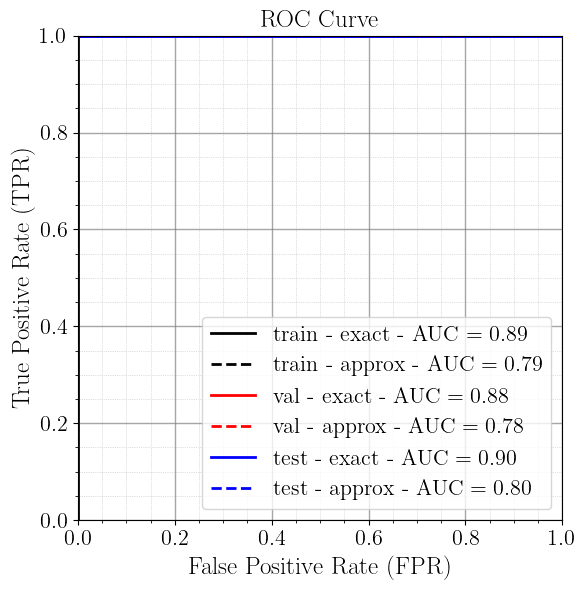

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ROC_curve returns two numpy arrays: FPR and TPR, both in [0,1].
FPR_train_exact, TPR_train_exact, AUC_train_exact = ROC_curve(x_train, omega_true, p_train)
FPR_train_approx, TPR_train_approx, AUC_train_approx = ROC_curve(x_train, omega_approx, p_train)
FPR_val_exact, TPR_val_exact, AUC_val_exact = ROC_curve(x_val, omega_true, p_val)
FPR_val_approx, TPR_val_approx, AUC_val_approx = ROC_curve(x_val, omega_approx, p_val)
FPR_test_exact, TPR_test_exact, AUC_test_exact = ROC_curve(x_test, omega_true, p_test)
FPR_test_approx, TPR_test_approx, AUC_test_approx = ROC_curve(x_test, omega_approx, p_test)

# --- Define custom tick marks ---
x_major_ticks = np.arange(0, 1.01, 0.2)
x_minor_ticks = np.arange(0, 1.01, 0.05)
y_major_ticks = np.arange(0, 1.01, 0.2)
y_minor_ticks = np.arange(0, 1.01, 0.05)

# Enable LaTeX rendering for text (if a full TeX installation is available)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'

# --- Create the ROC plot ---
fig, ax = plt.subplots(figsize=(6, 6))  # Square figure for aspect ratio 1

# Plot the ROC curve as a joined red, thick line.
ax.plot(FPR_train_exact, TPR_train_exact, color='black', linewidth=2, label=r'$\text{train - exact - AUC} = %.2f$' % AUC_train_exact)
ax.plot(FPR_train_approx, TPR_train_approx, color='black', linestyle='--', linewidth=2, label=r'$\text{train - approx - AUC} = %.2f$' % AUC_train_approx)
ax.plot(FPR_val_exact, TPR_val_exact, color='red', linewidth=2, label=r'$\text{val - exact - AUC} = %.2f$' % AUC_val_exact)
ax.plot(FPR_val_approx, TPR_val_approx, color='red', linestyle='--', linewidth=2, label=r'$\text{val - approx - AUC} = %.2f$' % AUC_val_approx)
ax.plot(FPR_test_exact, TPR_test_exact, color='blue', linewidth=2, label=r'$\text{test - exact - AUC} = %.2f$' % AUC_test_exact)
ax.plot(FPR_test_approx, TPR_test_approx, color='blue', linestyle='--', linewidth=2, label=r'$\text{test - approx - AUC} = %.2f$' % AUC_test_approx)

# Set title
plt.title(r'$\text{ROC Curve}$', fontsize = 18)

# Set the plot range.
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set the aspect ratio to 1.
ax.set_aspect('equal')

# Set custom major and minor ticks.
ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)
ax.tick_params(axis='both', which='major', labelsize=16)

# Set axis labels in LaTeX.
ax.set_xlabel(r'$\text{False Positive Rate (FPR)}$', fontsize=18)
ax.set_ylabel(r'$\text{True Positive Rate (TPR)}$', fontsize=18)

# Add a legend in the lower right.
ax.legend(loc='lower right', fontsize=16)

# Optionally, add grid lines for better readability.
ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(which='major', linestyle='-', linewidth=1, color='gray', alpha=0.7)

plt.tight_layout()

# Save the figure as a PDF file.
plt.savefig(f'/Users/rtorre/Dropbox/Apps/Overleaf/ML Methods for Physics/Figures/Chapter_3/logistic_approx_solution_roc.pdf')

plt.show()

## PyTorch (to be completed)